# SCSA Tutorial 1: Basic 1D Signal Reconstruction

This notebook demonstrates the fundamentals of using SCSA for 1D signal processing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pyscsa import SCSA1D, add_noise
from pyscsa.utils import SignalGenerator
from pyscsa.visualization import SCSAVisualizer

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

## 1. Generate Test Signal
We'll start with a sech-squared potential, commonly used in quantum mechanics.

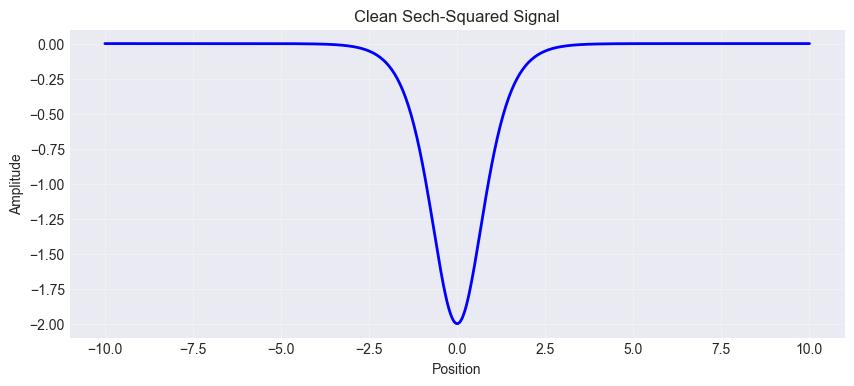

In [2]:
# Generate signal
x = np.linspace(-10, 10, 500)
signal = SignalGenerator.sech_squared(x, center=0, width=1)

# Visualize
plt.figure(figsize=(10, 4))
plt.plot(x, signal, 'b-', linewidth=2)
plt.xlabel('Position')
plt.ylabel('Amplitude')
plt.title('Clean Sech-Squared Signal')
plt.grid(True, alpha=0.3)
plt.show()

## 2. Add Noise and Apply SCSA

In [3]:
# Add noise
noisy_signal = add_noise(signal, snr_db=15, seed=42)

# Create SCSA instance
scsa = SCSA1D(gmma=0.5)

# Reconstruct with fixed h
result_clean = scsa.reconstruct(signal, h = 1.0)  
result_noise = scsa.reconstruct(noisy_signal, h=1.0)

print(f'Fixed h reconstruction noisy signal:')
print(f'  Number of eigenvalues: {result_noise.num_eigenvalues}')
print(f'  MSE: {result_noise.metrics["mse"]:.6f}')
print(f'  PSNR: {result_noise.metrics["psnr"]:.2f} dB')

print(f'Fixed h reconstruction clean signal:')
print(f'  Number of eigenvalues: {result_clean.num_eigenvalues}')
print(f'  MSE: {result_clean.metrics["mse"]:.6f}')
print(f'  PSNR: {result_clean.metrics["psnr"]:.2f} dB')

Fixed h reconstruction noisy signal:
  Number of eigenvalues: 217
  MSE: 4.451893
  PSNR: 1.11 dB
Fixed h reconstruction clean signal:
  Number of eigenvalues: 209
  MSE: 3.980774
  PSNR: 0.02 dB


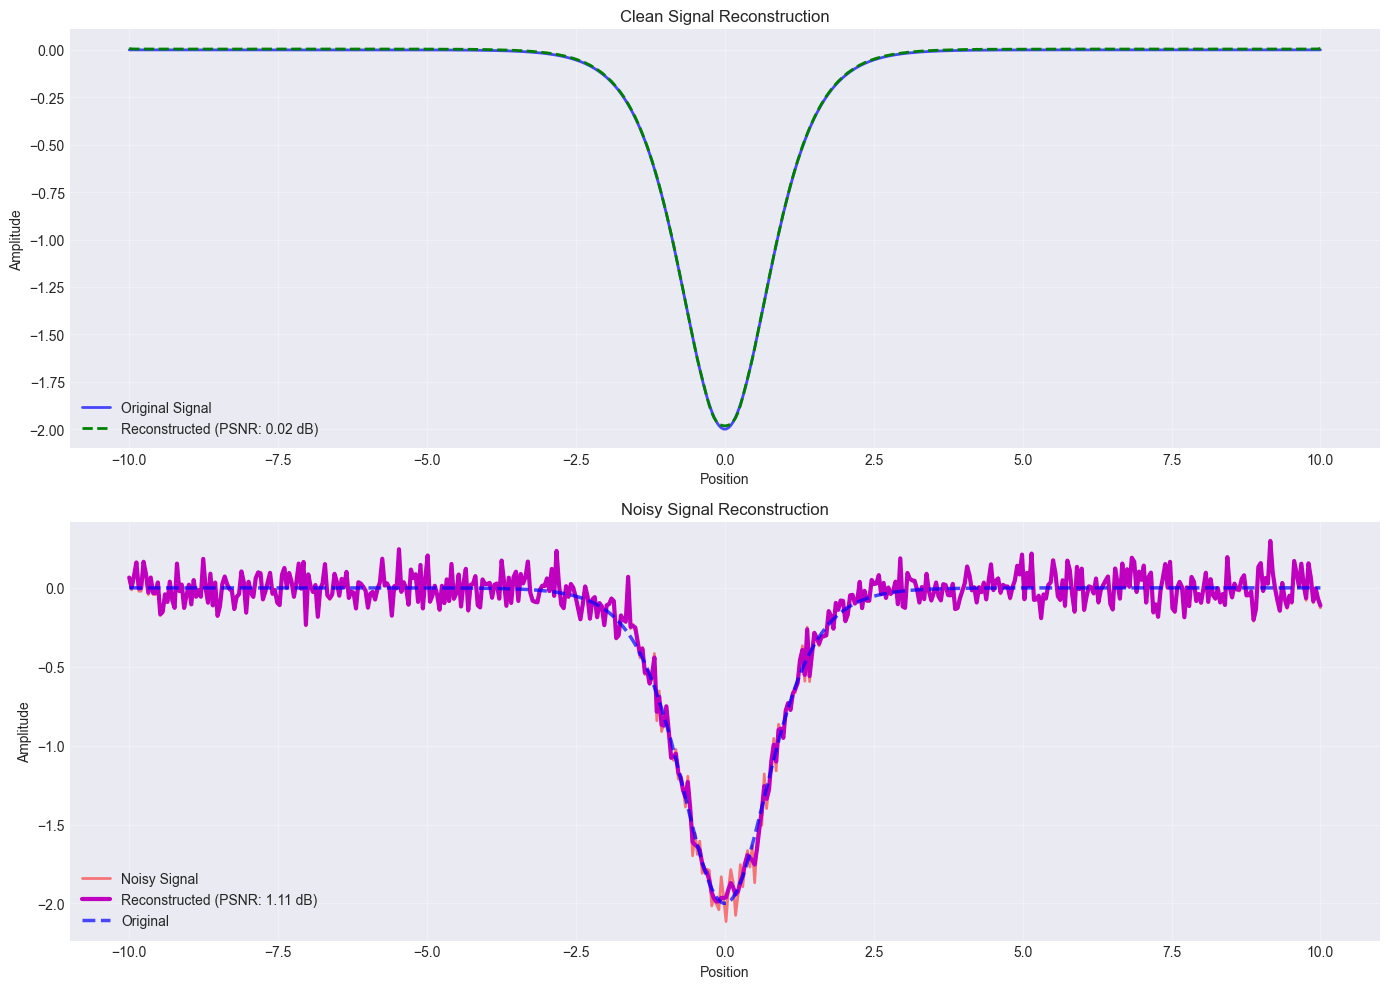

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Clean signal comparison
axes[0].plot(x, signal, 'b-', linewidth=2, label='Original Signal', alpha=0.7)
axes[0].plot(x, result_clean.reconstructed, 'g--', linewidth=2, label=f'Reconstructed (PSNR: {result_clean.metrics["psnr"]:.2f} dB)')
axes[0].set_title('Clean Signal Reconstruction')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Amplitude')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Noisy signal comparison
axes[1].plot(x, noisy_signal, 'r-', linewidth=2, alpha=0.5, label='Noisy Signal')
axes[1].plot(x, result_noise.reconstructed, 'm-', linewidth=3, label=f'Reconstructed (PSNR: {result_noise.metrics["psnr"]:.2f} dB)')
axes[1].plot(x, signal, 'b--', linewidth=2.5, alpha=0.7, label='Original')
axes[1].set_title('Noisy Signal Reconstruction')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Amplitude')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()